Importing

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [72]:
df = pd.read_csv("data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


create column "Country"

In [73]:
df["Country"]="kenya"

changing date

In [74]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change month to name

In [75]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [76]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [77]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [78]:
df = df.drop_duplicates()

describe 

In [79]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN


The dataset contains 4,108 observations from 2015 to 2026 with no missing values, indicating good data quality. The average temperature (T2M) is 20.4°C, with values ranging from 15.26°C to 25.4°C, showing a moderate and stable climate. Daily temperature variation (T2M_RANGE) averages 13.17°C, indicating noticeable differences between day and night temperatures. Precipitation (PRECTOTCORR) has a low mean of 1.47 mm but reaches up to 51.65 mm, suggesting a right-skewed distribution with occasional heavy rainfall events. Humidity (RH2M) averages 65.8%, with moderate variability, while wind speeds are generally moderate (mean ≈ 3.06 m/s). Surface pressure (PS) is highly stable with minimal variation. Overall, the dataset reflects a moderate climate with stable temperatures, moderate humidity, and irregular precipitation, and it is well-prepared for further analysis due to the absence of missing data.

number of Nan

In [80]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [81]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [82]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [83]:
z_scores = np.abs(stats.zscore(df[cols]))

In [84]:
outliers_mask=(z_scores>3).any(axis=1)

In [85]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 121


Z-score analysis was performed on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) using a threshold of |Z| > 3 to detect extreme values. The analysis identified 121 rows as outliers, indicating a moderate presence of unusual observations in the dataset. These outliers are mainly associated with precipitation and wind speed variations, along with a few temperature and humidity extremes, which are typical in climate datasets due to natural variability. In most cases, such values may reflect genuine extreme weather events rather than errors, so they should generally be retained for analysis. However, to improve model stability and reduce the influence of extreme values, it is recommended to apply robust techniques such as log transformation, capping (winsorization), or scaling in further statistical and machine learning analyses.

Handling missing values

In [86]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [87]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [88]:
df_clean = df[~outliers_mask].copy()

In [89]:
print(f"Cleaned rows:{len(df)}")

Cleaned rows:4108


In [90]:
df.to_csv("data/kenya_clean.csv", index=False)

In [91]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [92]:
print(df_clean.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date',
       'Month_Name'],
      dtype='str')


In [93]:
for col in df.columns:
    print(repr(col))


'YEAR'
'DOY'
'T2M'
'T2M_MAX'
'T2M_MIN'
'T2M_RANGE'
'PRECTOTCORR'
'RH2M'
'WS2M'
'WS2M_MAX'
'PS'
'QV2M'
'Country'
'Date'
'Month_Name'


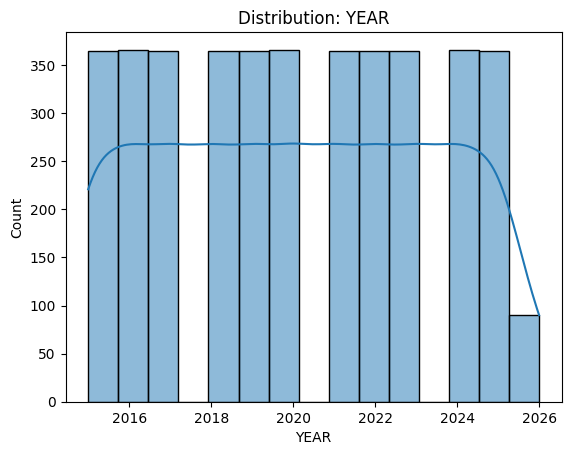

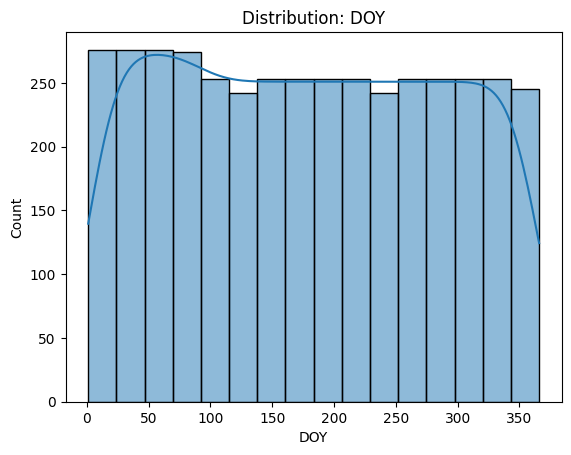

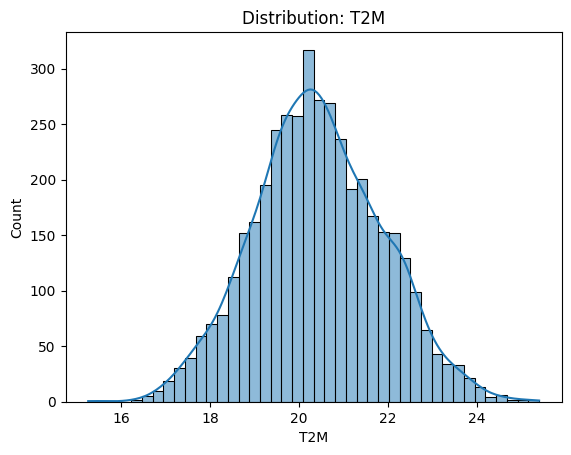

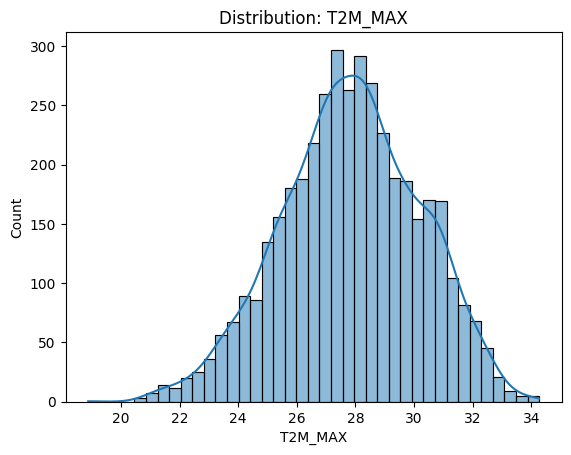

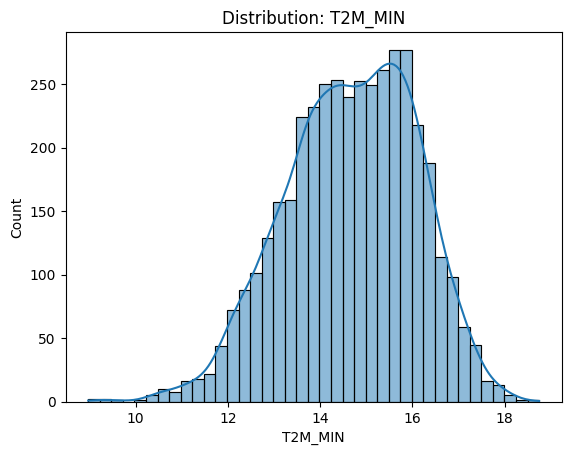

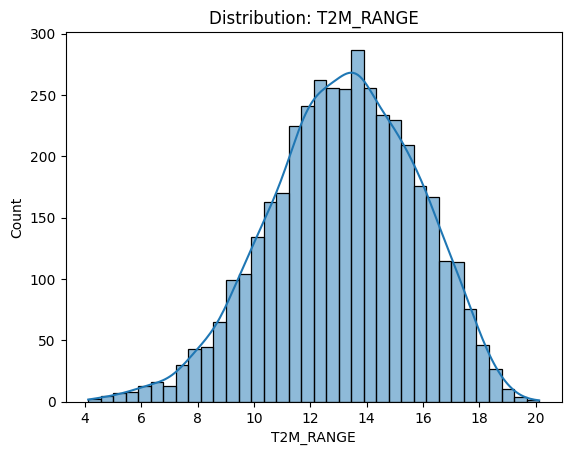

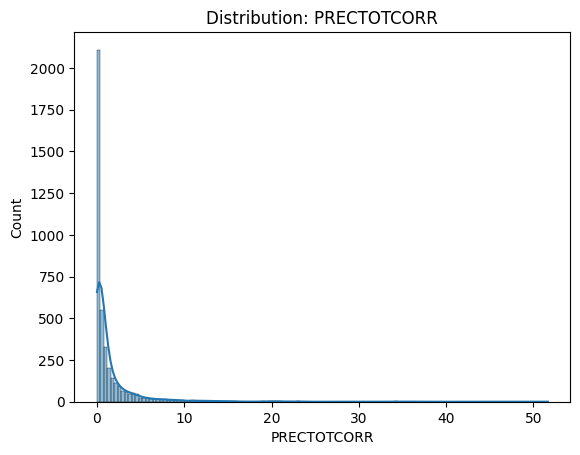

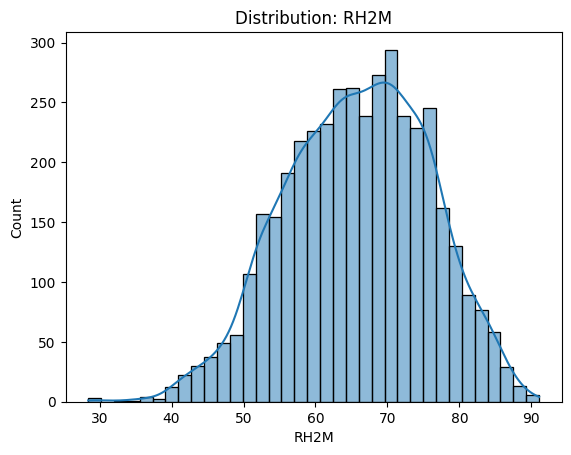

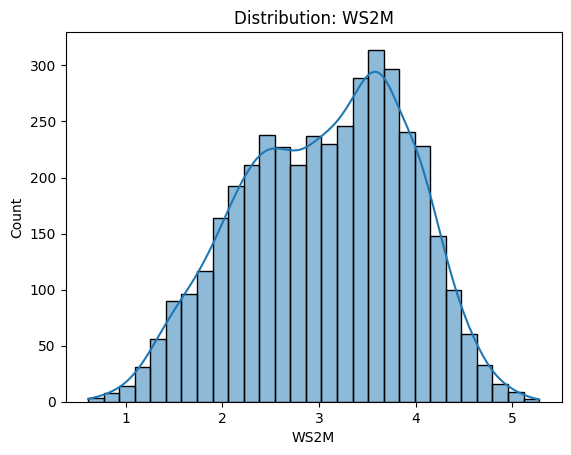

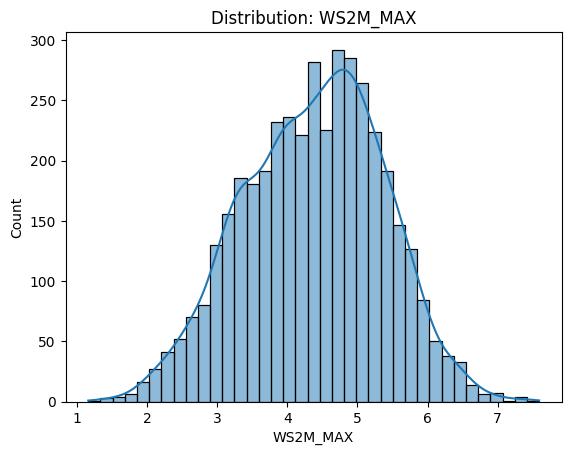

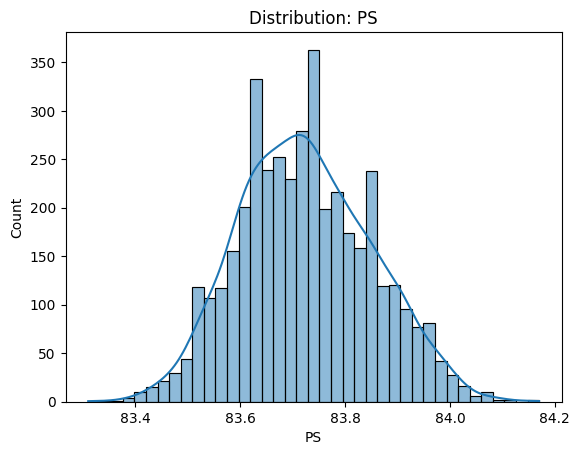

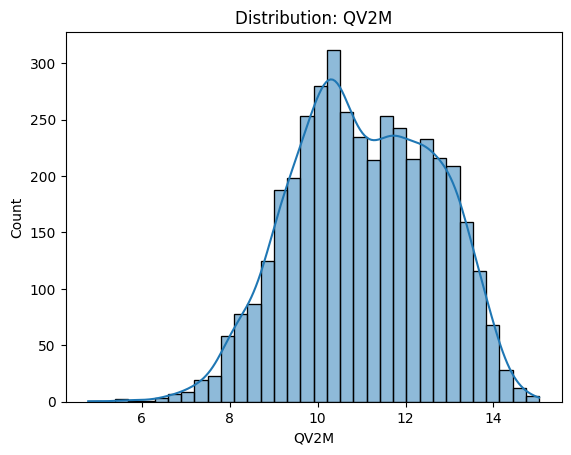

In [94]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    plt.figure()
    sns.histplot(df[c], kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

In [95]:

df_clean = df[~outliers_mask].copy()

Monthly average T2M

In [96]:

# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

In [97]:

monthly_t2m = df_clean["T2M"].resample("ME").mean()

Find warmest and coolest months

In [98]:

warmest_month = monthly_t2m.idxmax()
coolest_month = monthly_t2m.idxmin()
warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()


plot

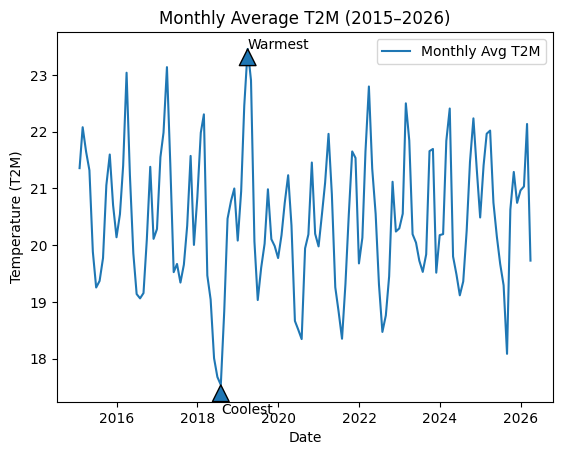

In [99]:
# Plot
plt.plot(monthly_t2m, label="Monthly Avg T2M")
# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_month, warmest_value),
             xytext=(warmest_month, warmest_value),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_month, coolest_value),
             xytext=(coolest_month, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

BAR chart for PRECTOTCORR

In [100]:
print(df_clean.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-01  2015    1  19.56    28.99    12.09      16.90         0.00  45.32   
2015-01-02  2015    2  19.63    29.77    11.04      18.73         0.00  38.76   
2015-01-03  2015    3  20.40    30.57    11.71      18.86         0.00  41.75   
2015-01-04  2015    4  21.33    31.20    13.02      18.18         3.49  51.87   
2015-01-05  2015    5  20.41    29.52    12.38      17.14         1.79  48.04   

            WS2M  WS2M_MAX     PS  QV2M Country Month_Name  
Date                                                        
2015-01-01  3.12      4.76  83.68  6.88   kenya    January  
2015-01-02  3.23      4.35  83.67  5.85   kenya    January  
2015-01-03  3.46      4.68  83.69  6.65   kenya    January  
2015-01-04  2.29      4.00  83.62  8.60   kenya    January  
2015-01-05  1.77      4.05  83.54  7.64   kenya    January  


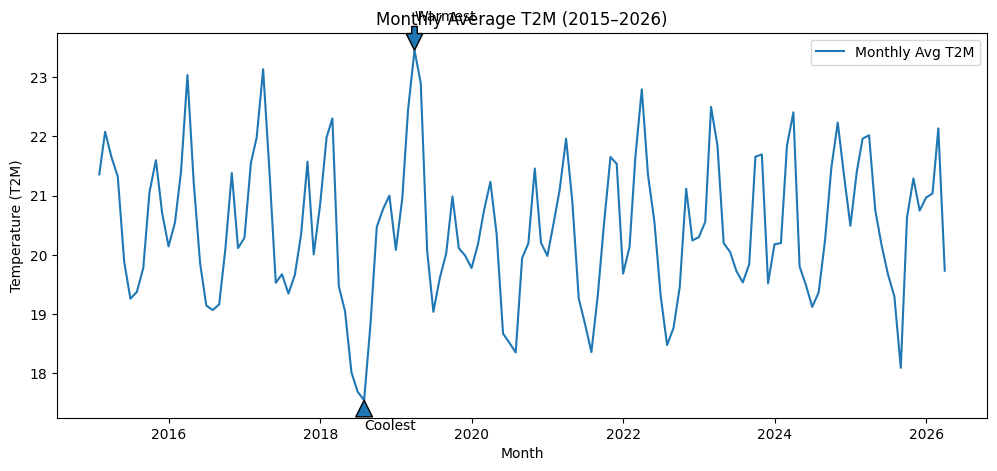

In [101]:


# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


The monthly average temperature (T2M) shows a relatively stable pattern over the 2015–2026 period, fluctuating within a narrow range with no strong long-term upward or downward trend. However, there are clear seasonal oscillations, with periodic peaks (warm months) and dips (cool months), indicating consistent climate seasonality. A notable cold anomaly appears around 2018–2019, while the warmest peaks occur around 2019–2020 and again in later years, though overall variation remains moderate. Temperature is stable and seasonal.

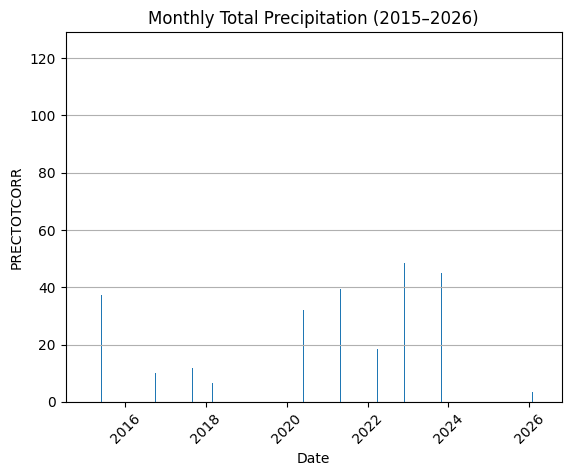

In [102]:
# Monthly average T2M
monthly_precip = df_clean["PRECTOTCORR"].resample("ME").sum()
plt.bar(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

The monthly total precipitation (PRECTOTCORR) is highly irregular and sparse. Most months show very low or near-zero rainfall, with occasional sharp spikes. These spikes (e.g., around 2015, 2020–2023) represent extreme rainfall events, highlighting a strongly right-skewed and event-driven pattern. There is no clear seasonal consistency in precipitation, suggesting that rainfall is episodic rather than continuous. Precipitation is highly variable with frequent anomalies.

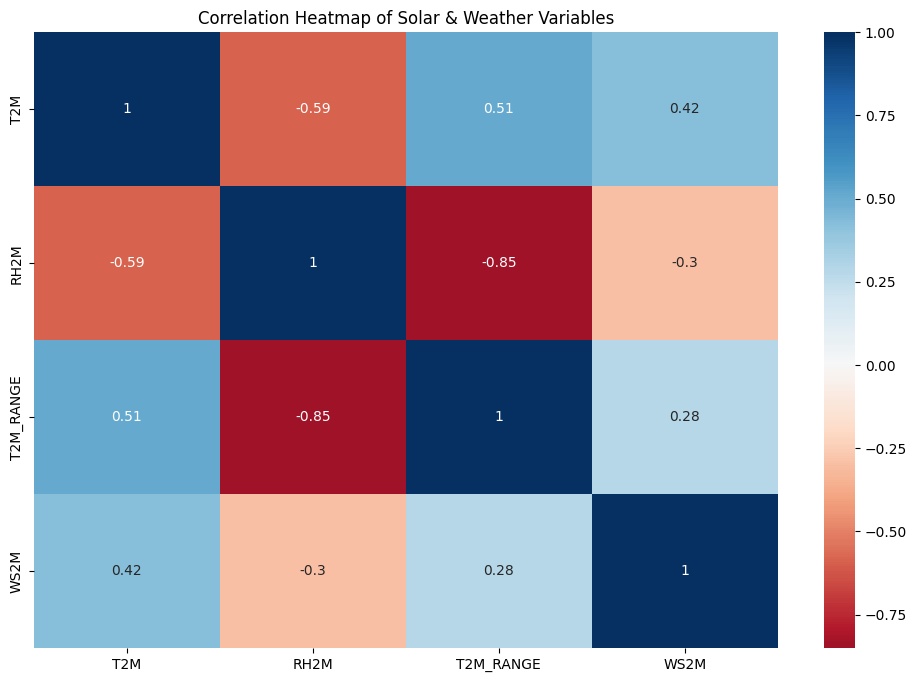

In [103]:

#selecting main columns for correlation
corr_cols = ['T2M', 'RH2M', 'T2M_RANGE', 'WS2M']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

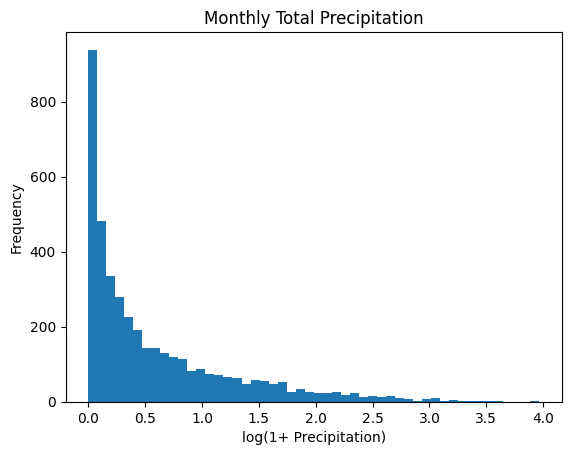

In [104]:


plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=50)
plt.title("Monthly Total Precipitation")
plt.xlabel("log(1+ Precipitation)")
plt.ylabel("Frequency")
plt.show()

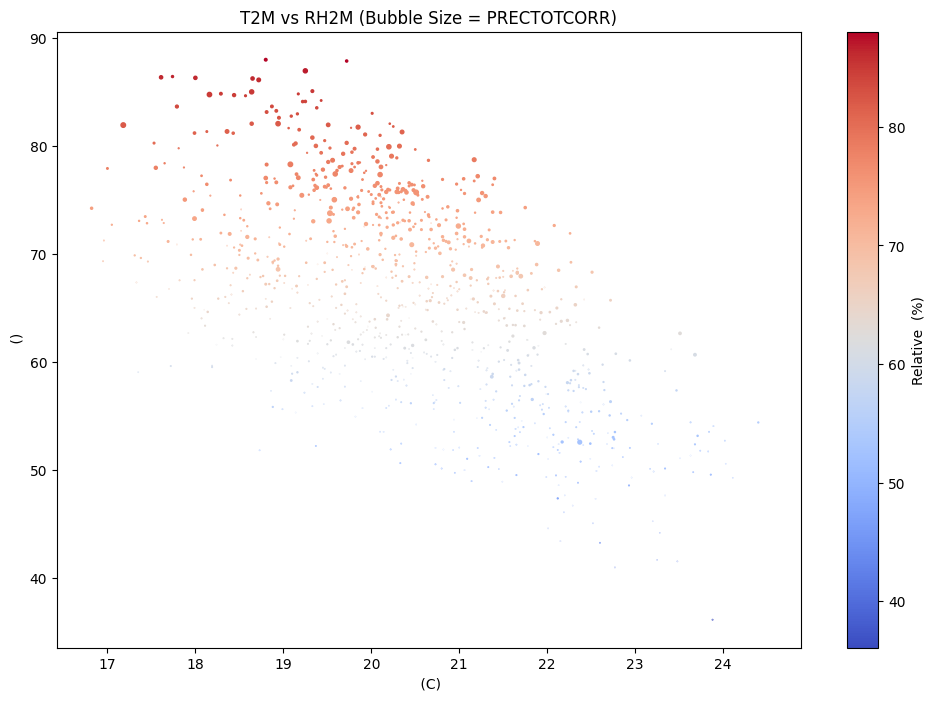

In [105]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['T2M'], sample_bubble['RH2M'], 
            s=sample_bubble['PRECTOTCORR'], # Size of bubble
            c=sample_bubble['RH2M'], # Color can also 
            cmap='coolwarm')

plt.title('T2M vs RH2M (Bubble Size = PRECTOTCORR)')
plt.xlabel(' (C)')
plt.ylabel(' ()')
plt.colorbar(label='Relative  (%)')
plt.show()
